# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [1]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков

%matplotlib inline

Прочитаем исходные данные:

In [2]:
data = pd.read_csv('unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

Статистическое описание:


,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,57.879185,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,1.000000,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,50.750000,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,100.500000,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,150.250000,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,200.000000,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


Пропуски:
Well       0
Por        0
Perm       0
AI         0
Brittle    0
TOC        0
VR         0
Prod       0
dtype: int64
Дубликаты: 0


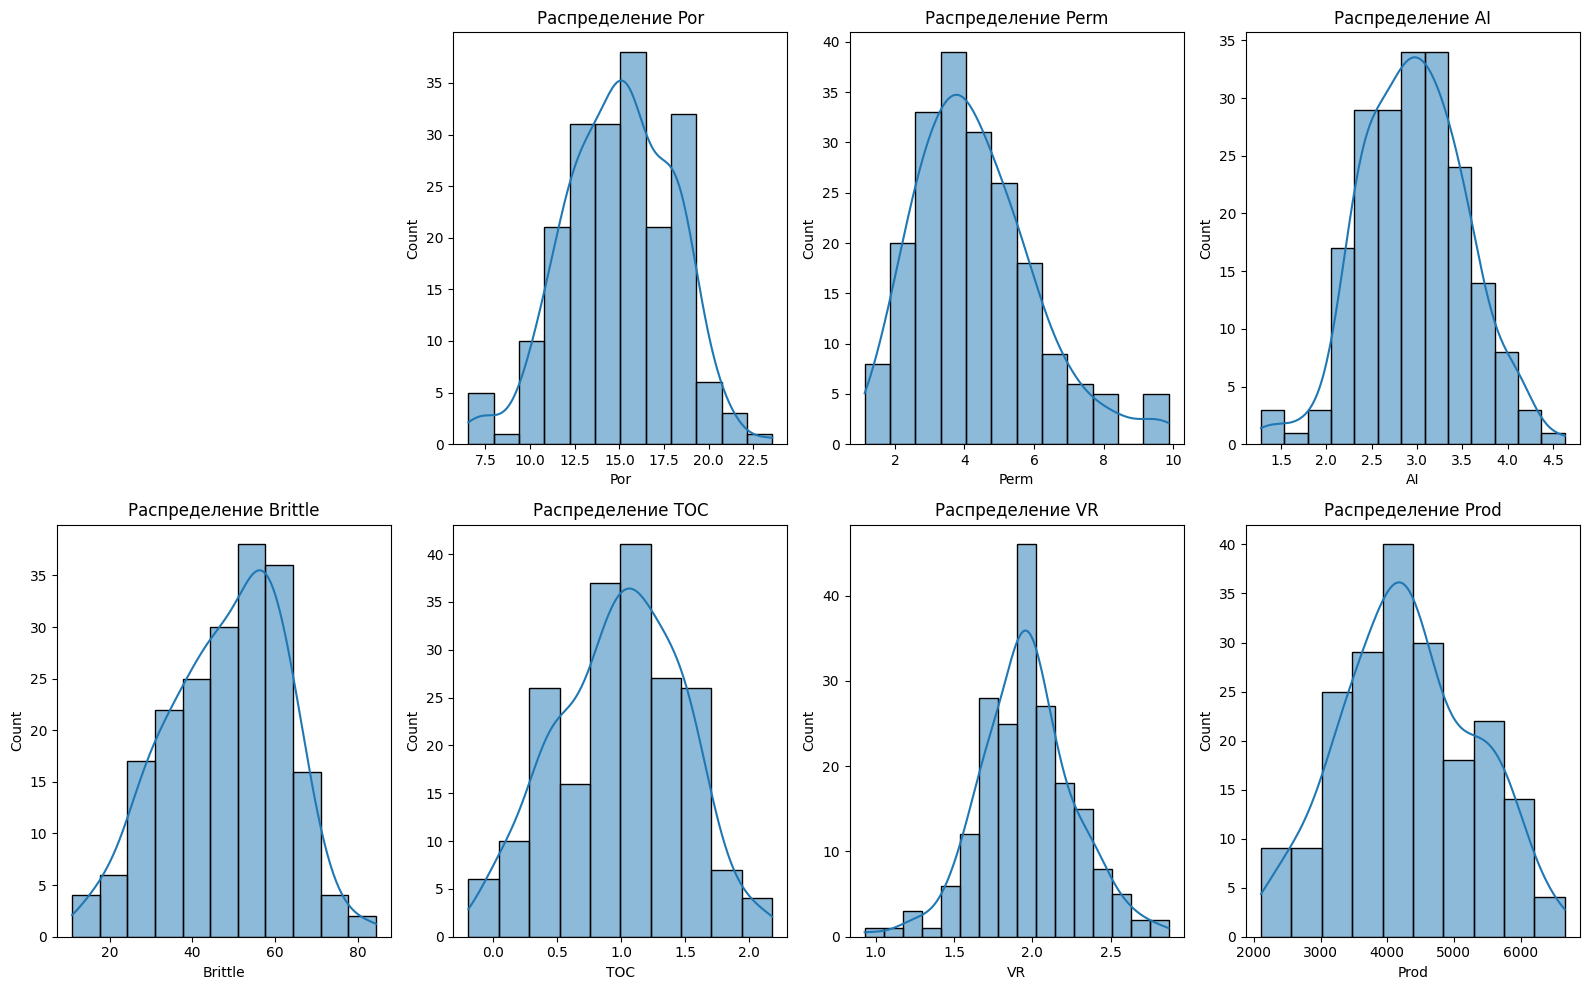

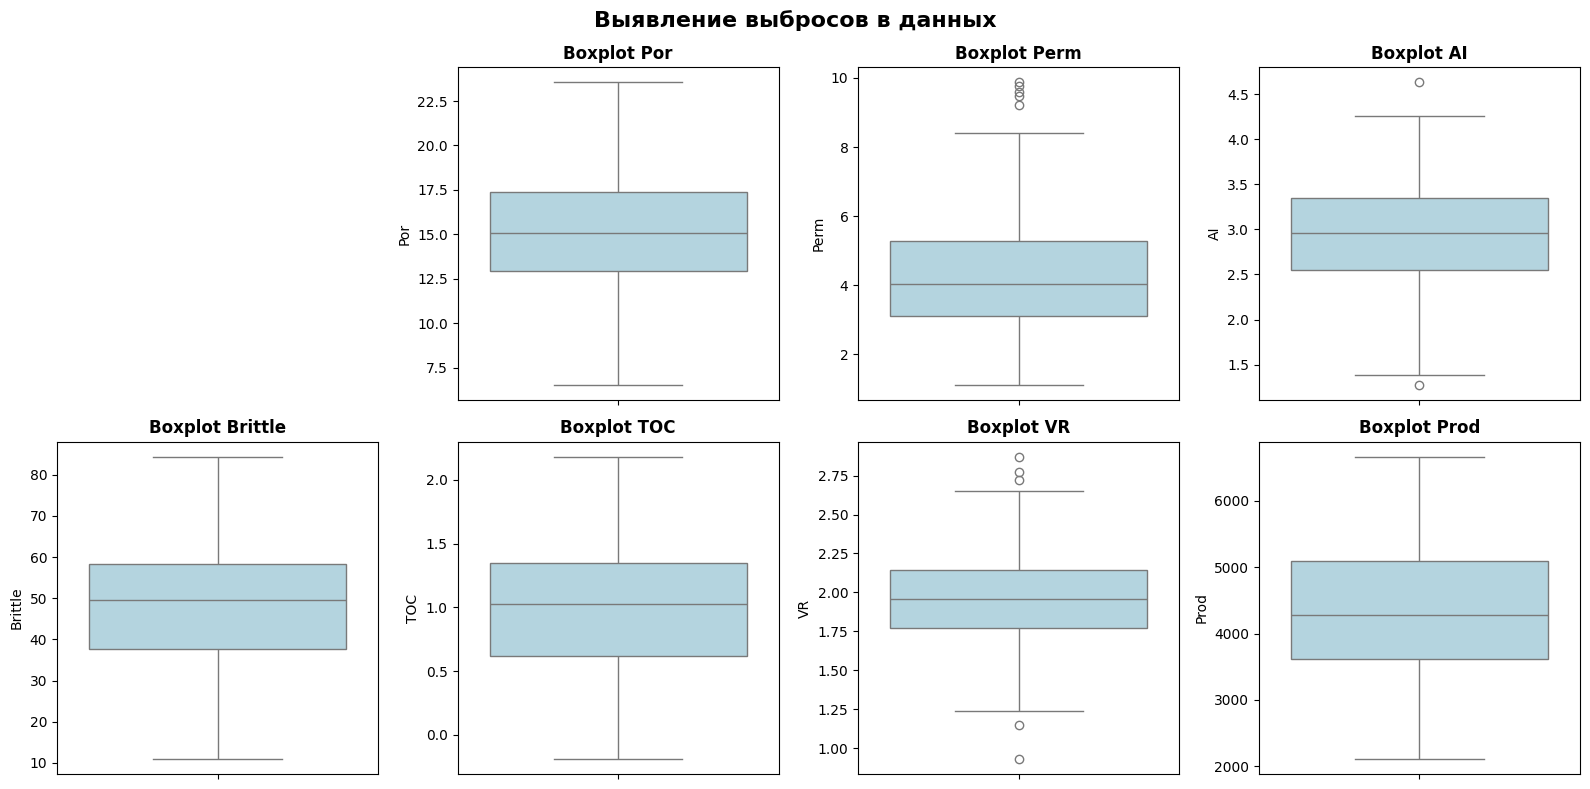

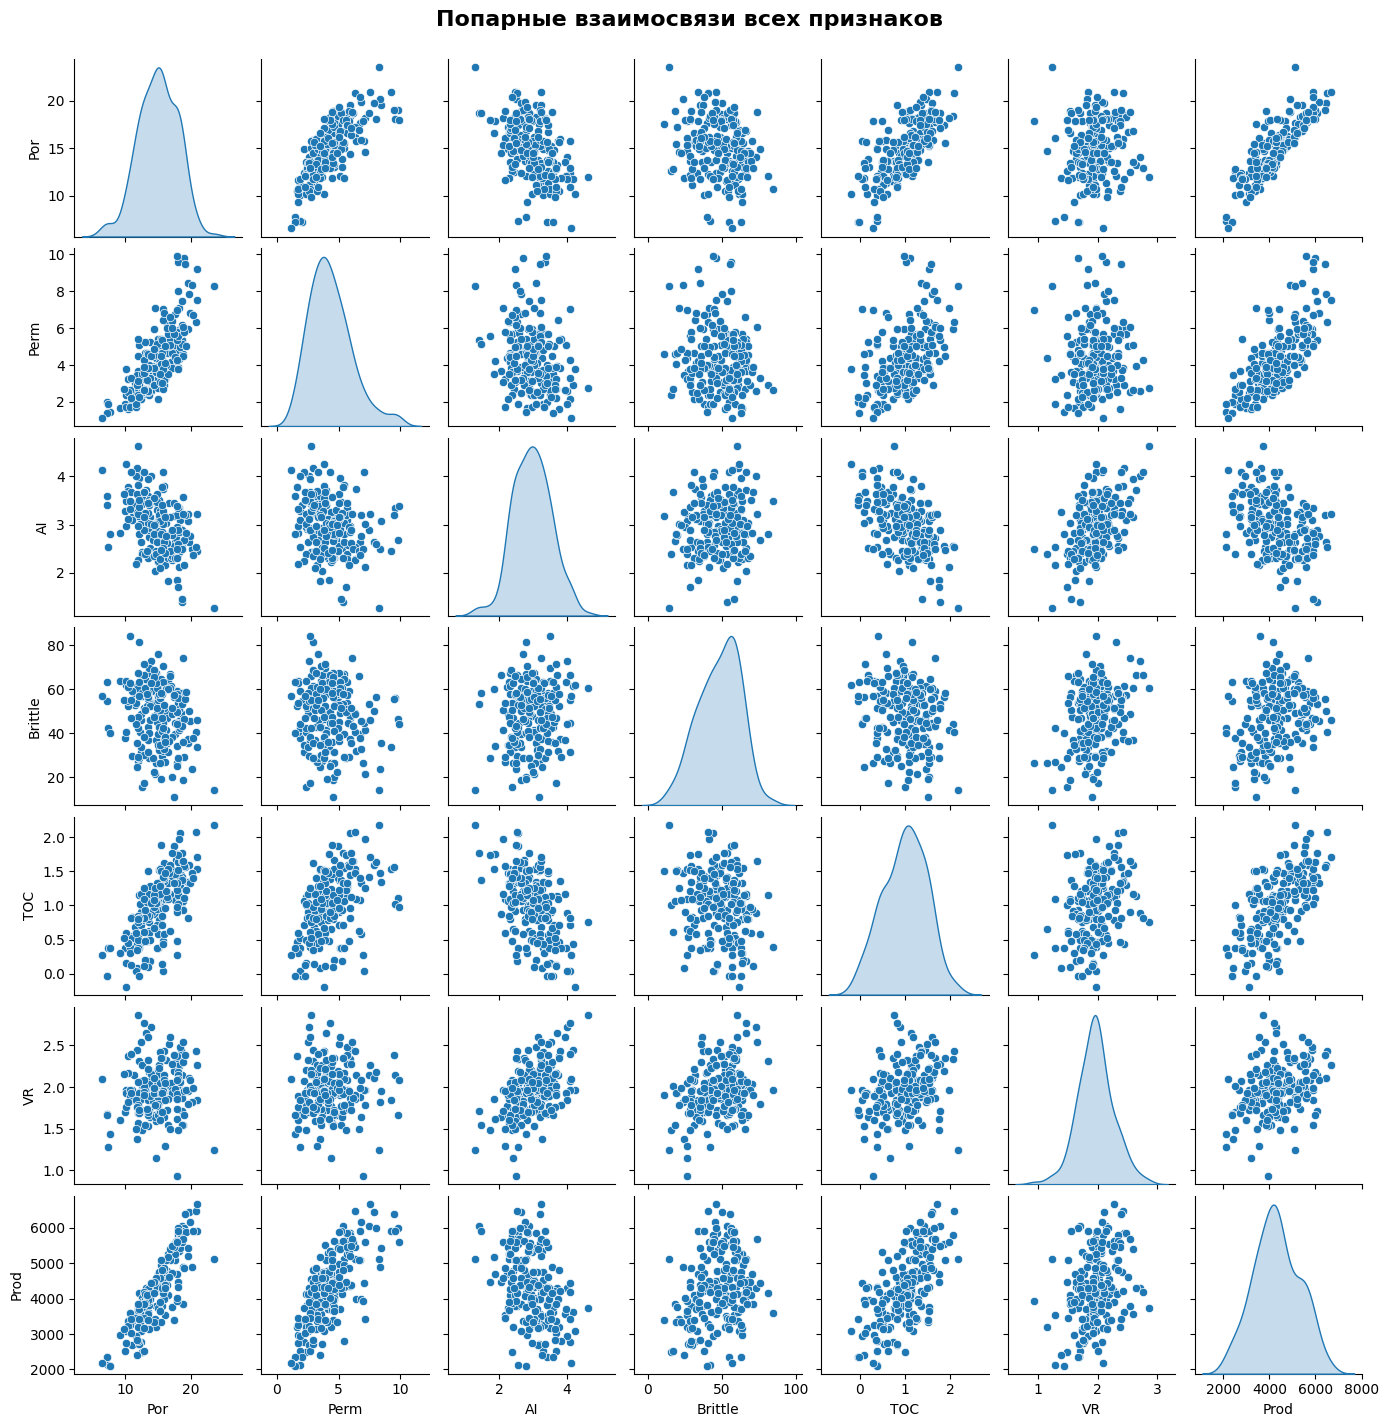

In [3]:
# Ваш код здесь

# Статистическое описание данных
print("Статистическое описание:")
display(data.describe())

# Проверка пропусков и дубликатов
print(f"Пропуски:\n{data.isnull().sum()}")
print(f"Дубликаты: {data.duplicated().sum()}")

# Визуализация распределений признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    if col != 'Well':
        sns.histplot(data[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Ящики с усами для выявления выбросов
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    if col != 'Well':
        sns.boxplot(y=data[col], ax=axes[i], color='lightblue')
        axes[i].set_title(f'Boxplot {col}', fontweight='bold')
        axes[i].set_ylabel(col)
    else:
        axes[i].set_visible(False)

plt.suptitle('Выявление выбросов в данных', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Визуализация взаимосвязей

# Pairplot для ключевых признаков
sns.pairplot(data.drop('Well', axis=1), 
             vars=['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod'],
             diag_kind='kde', height=2)
plt.suptitle('Попарные взаимосвязи всех признаков', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

              Por      Perm        AI   Brittle       TOC        VR      Prod
Por      1.000000  0.760546 -0.461549 -0.218570  0.711831  0.111860  0.861910
Perm     0.760546  1.000000 -0.239636 -0.124017  0.471746  0.051023  0.727426
AI      -0.461549 -0.239636  1.000000  0.127599 -0.531864  0.499143 -0.390835
Brittle -0.218570 -0.124017  0.127599  1.000000 -0.214282  0.317929  0.237155
TOC      0.711831  0.471746 -0.531864 -0.214282  1.000000  0.299483  0.654445
VR       0.111860  0.051023  0.499143  0.317929  0.299483  1.000000  0.323182
Prod     0.861910  0.727426 -0.390835  0.237155  0.654445  0.323182  1.000000


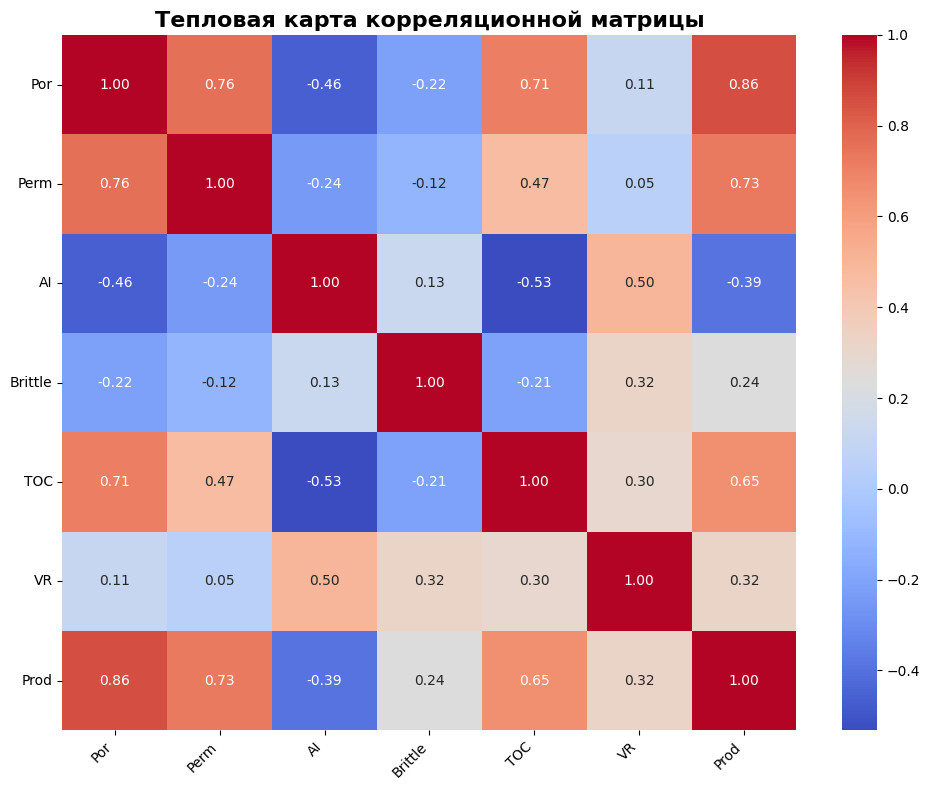

Ранг матрицы: 7

Определитель матрицы: 0.0007477684988022884


In [4]:
# Ваш код здесь
# Создание корреляционной матрицы (исключаем столбец Well)
corr_matrix = data.drop('Well',axis=1).corr()
print(corr_matrix)

# Тепловая карта корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,           
            fmt='.2f',            
            cmap='coolwarm')      

plt.title('Тепловая карта корреляционной матрицы', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Вычисление ранга и определителя корреляционной матрицы
rank = np.linalg.matrix_rank(corr_matrix)
det = np.linalg.det(corr_matrix)
print(f"Ранг матрицы: {rank}")
print(f"\nОпределитель матрицы: {det}")

> *Ваши выводы здесь*

### Сильнее всего с Prod коррелируют: 
#### Por (пористость) - коэффициент корреляции 0.86
#### Perm (проницаемость) - коэффициент корреляции 0.73

### Определитель близок к нулю, но не является критически малым. Значение 0.000747 указывает на то, что матрица не вырождена, а некоторые признаки сильно скоррелированы между собой, что приводит к нестабильности оценок коэффициентов регрессии.

### В данных присутствует мультиколлинеарность

### Модель классической линейной регрессии (МНК) применима, так как признаки действительно связаны с Prod, а матрица не вырождена, однако не рекомендуется из-за плохой обусловленности матрицы. Малый определитель = 0.000747 означает, что даже небольшие изменения в данных могут привести к сильным изменениям в коэффициентах регрессии, что делает модель ненадёжной для прогнозирования на новых данных.

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [5]:
# Ваш код здесь
# Создание матрицы наблюдений X и вектора ответов y
X = data[['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']].values
y = data['Prod'].values

# Добавляем столбец единиц для свободного члена (intercept)
X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])

# Решение МНК матричным способом
XTX = X_with_intercept.T @ X_with_intercept
XTX_inv = np.linalg.inv(XTX)
XTy = X_with_intercept.T @ y
beta = XTX_inv @ XTy

# Коэффициенты модели
feature_names = ['Intercept', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
coefficients = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': beta
})
print(coefficients.round(0).to_string(index=False))

  Признак  Коэффициент
Intercept      -1230.0
      Por        230.0
     Perm        116.0
       AI       -364.0
  Brittle         25.0
      TOC        -77.0
       VR        783.0


> *Ваши выводы здесь*
### Да, в данных есть признаки, которые можно считать неинформативными или слабоинформативными: 
#### Brittle (коэффициент 25)
#### TOC (коэффициент -77)
#### Perm (коэффициент 116)
### Интерпретация 1: Коэффициент при VR (коэффициент отражения витринита): при увеличении коэффициента отражения витринита на 1% (при прочих равных условиях), добыча газа увеличивается в среднем на 783 млн куб. футов в сутки.
### Интерпретация 2: Коэффициент при Por (пористость): при увеличении пористости на 1% (при прочих равных условиях), добыча газа увеличивается в среднем на 230 млн куб. футов в сутки.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [6]:
# Ваш код здесь
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Часть а) Прогноз для конкретной скважины

# Данные скважины
well_106 = {
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
}

# Создаём вектор признаков для прогноза
X_new = np.array([1.0, well_106['Por'], well_106['Perm'], 
                  well_106['AI'], well_106['Brittle'], 
                  well_106['TOC'], well_106['VR']])

# Расчёт прогноза
prediction = X_new @ beta

# Фактическое значение
actual = 4748.315024

# Расчёт абсолютной ошибки
absolute_error = abs(actual - prediction)
print(f"Абсолютная ошибка: {absolute_error:.2f}")

# Часть б) Прогноз для всех скважин 
# Прогноз для всех скважин
y_pred = X_with_intercept @ beta

# Добавляем прогнозы в DataFrame
data_with_pred = data.copy()
data_with_pred['Predicted_Prod'] = y_pred
data_with_pred['Error'] = data_with_pred['Prod'] - data_with_pred['Predicted_Prod']
data_with_pred['Abs_Error'] = np.abs(data_with_pred['Error'])
# MAE (Mean Absolute Error) - основная метрика
mae = mean_absolute_error(y, y_pred)
print(f"MAE: {mae:.2f} ")
# RMSE (Root Mean Squared Error) - дополнительная метрика
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.2f}")


Абсолютная ошибка: 25.59
MAE: 153.60 
RMSE: 198.30


> *Ваши выводы здесь*
### Часть А
#### Интерпретация:
#### Модель предсказала добычу для скважины с ошибкой 25.59, что является хорошей точностью для конкретной скважины.
### Часть Б
#### Интерпретация:
#### Модель демонстрирует хорошее качество прогнозирования. В среднем ошибка составляет 153.6, что является хорошим результатом для геологической задачи. Разница между RMSE и MAE(45%) указывает на наличие выбросов, что требует дальнейшего анализа и улучшения модели.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

In [7]:
# Ваш код здесь
correlations = corr_matrix['Prod'].drop('Prod')

# Коэффициенты модели (из предыдущего задания)
# Используем полученные ранее значения
coefficients = {
    'Por': 230,
    'Perm': 116,
    'AI': -364,
    'Brittle': 25,
    'TOC': -77,
    'VR': 783
}

# Создание DataFrame для сравнения
comparison = pd.DataFrame({
    'Признак': list(coefficients.keys()),
    'Коэффициент_модели': list(coefficients.values()),
    'Корреляция': [correlations[feat] for feat in coefficients.keys()]
})
# Определяем знаки
comparison['Знак_коэффициента'] = comparison['Коэффициент_модели'].apply(lambda x: '+' if x > 0 else '-')
comparison['Знак_корреляции'] = comparison['Корреляция'].apply(lambda x: '+' if x > 0 else '-')
comparison['Совпадение_знаков'] = comparison['Знак_коэффициента'] == comparison['Знак_корреляции']
print(comparison.to_string(index=False))

Признак  Коэффициент_модели  Корреляция Знак_коэффициента Знак_корреляции  Совпадение_знаков
    Por                 230    0.861910                 +               +               True
   Perm                 116    0.727426                 +               +               True
     AI                -364   -0.390835                 -               -               True
Brittle                  25    0.237155                 +               +               True
    TOC                 -77    0.654445                 -               +              False
     VR                 783    0.323182                 +               +               True


> *Ваши выводы здесь*

#### Да, есть один такой фактор - TOC (общий органический углерод).
#### Противоречие для TOC связано с мультиколлинеарностью 

### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [8]:
# Ваш код здесь
print(correlations.sort_values(ascending=False).round(2))
# Выявление пар с корреляцией > 0.7
threshold = 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
# Удаляем сильно коррелированные факторы (> 0.7)
# Для каждой пары оставляем признак с большей корреляцией с Prod
features_to_remove = set()
for feat1, feat2, corr in high_corr_pairs:
    # Проверяем, что признаки есть в correlations
    if feat1 in correlations.index and feat2 in correlations.index:
        if abs(correlations[feat1]) > abs(correlations[feat2]):
            keep = feat1
            remove = feat2
        else:
            keep = feat2
            remove = feat1
        print(f"Оставляем: {keep} (корр. с Prod = {correlations[keep]:.2f})")
        print(f"Удаляем: {remove} (корр. с Prod = {correlations[remove]:.2f})")
        features_to_remove.add(remove)
# Удаляем признаки с корреляцией с Prod < 0.05
low_corr_features = correlations[abs(correlations) < 0.05].index.tolist()
if low_corr_features:
    print(f"\n  Признаки с корреляцией < 0.05:")
    for feat in low_corr_features:
        print(f"Удаляем: {feat} (корреляция = {correlations[feat]:.2f})")
        features_to_remove.add(feat)
else:
    print(f"\nНет признаков с корреляцией < 0.05")
# Формируем итоговый список признаков
all_features = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
selected_features = [feat for feat in all_features if feat not in features_to_remove]
# Создание матрицы наблюдений X и вектора ответов y
X_new = data[selected_features].values
y = data['Prod'].values

# Добавляем столбец единиц для свободного члена (intercept)
X_new_with_intercept = np.column_stack([np.ones(X_new.shape[0]), X_new])

# Решение МНК матричным способом
XTX_new = X_new_with_intercept.T @ X_new_with_intercept
XTX_inv_new = np.linalg.inv(XTX_new)
XTy_new = X_new_with_intercept.T @ y
beta_new = XTX_inv_new @ XTy_new

# Коэффициенты модели
feature_names_new = ['Intercept'] + selected_features
coefficients_new = pd.DataFrame({
    'Признак': feature_names_new,
    'Коэффициент': beta_new
})
# Прогноз для всех скважин
y_pred_new = X_new_with_intercept @ beta_new
# Расчёт метрик
mae_new = mean_absolute_error(y, y_pred_new)
rmse_new = np.sqrt(mean_squared_error(y, y_pred_new))
print("\n")
print(coefficients_new.round(0).to_string(index=False))
print(f"\nМетрики новой модели:")
print(f"MAE: {mae_new:.2f}")
print(f"RMSE:{rmse_new:.2f} ")

Por        0.86
Perm       0.73
TOC        0.65
VR         0.32
Brittle    0.24
AI        -0.39
Name: Prod, dtype: float64
Оставляем: Por (корр. с Prod = 0.86)
Удаляем: Perm (корр. с Prod = 0.73)
Оставляем: Por (корр. с Prod = 0.86)
Удаляем: TOC (корр. с Prod = 0.65)

Нет признаков с корреляцией < 0.05


  Признак  Коэффициент
Intercept      -1835.0
      Por        293.0
       AI       -200.0
  Brittle         28.0
       VR        517.0

Метрики новой модели:
MAE: 171.43
RMSE:231.65 


> *Ваши выводы здесь*

### Интерпретация коэффициентов
#### Коэффициент при Por (пористость): 293 (было 230 в старой модели). При увеличении пористости на 1% (при прочих равных условиях), добыча газа увеличивается в среднем на 293 млн куб. футов в сутки.
#### Коэффициент при VR (коэффициент отражения витринита): 517 (было 783 в старой модели). При увеличении VR на 1% (при прочих равных условиях), добыча газа увеличивается в среднем на 517 млн куб. футов в сутки.

### Интерпретация метрик качества
#### Метрика	MAE - 171.43(было 153.60) - ухудшилась
#### Метрика RMSE - 231.65(было 198.30) - ухудшилась
### Да, противоречие полностью устранено, так как были удалены TOC и PERM.



### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [9]:
# Ваш код здесь
from sklearn.linear_model import LinearRegression
selected_features = ['Por', 'AI', 'Brittle', 'VR']
X = data[selected_features].values
y = data['Prod'].values
# Создание и обучение модели
model = LinearRegression()
model.fit(X, y)

# Получение коэффициентов
intercept = model.intercept_
coefficients = model.coef_

# Создание DataFrame для коэффициентов
coef_df = pd.DataFrame({
    'Признак': ['Intercept'] + selected_features,
    'Коэффициент_sklearn': [intercept] + list(coefficients)
})
print(coef_df.round(0).to_string(index=False))
# Прогноз
y_pred_sklearn = model.predict(X)
# Расчёт метрик
mae_sklearn = mean_absolute_error(y, y_pred_sklearn)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred_sklearn))
print(f"MAE:  {mae_sklearn:.2f}")
print(f"RMSE: {rmse_sklearn:.2f}")

  Признак  Коэффициент_sklearn
Intercept              -1835.0
      Por                293.0
       AI               -200.0
  Brittle                 28.0
       VR                517.0
MAE:  171.43
RMSE: 231.65


> *Ваши выводы здесь*
### Результаты сравнения:
#### Коэффициенты полностью совпадают
#### Метрики полностью совпадают
#### Обе реализации дают идентичные результаты, что подтверждает правильность ручных вычислений.

## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [10]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [30]:
# Ваш код здесь
# Используем отобранные признаки из задания 5.5
selected_features = ['Por', 'AI', 'Brittle', 'VR']
X = data[selected_features].values
y = data['Prod'].values
# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Генерация полиномиальных признаков третьей степени
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
# Количество признаков
n_features_original = X_scaled.shape[1]
n_features_poly = X_poly.shape[1]
print(f"Количество полиномиальных признаков: {X_poly.shape[1]}")
# Обучение модели линейной регрессии на полиномиальных признаках
model = LinearRegression()
# Кросс-валидация с несколькими метриками
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}
cv_results = cross_validate(
    model, 
    X_poly, 
    y, 
    cv=5,  
    scoring=scoring,
    return_train_score=True,
    return_estimator=True
)
# Извлечение результатов
train_mae = -cv_results['train_MAE']
test_mae = -cv_results['test_MAE']
train_rmse = -cv_results['train_RMSE']
test_rmse = -cv_results['test_RMSE']
print(f"Среднее значение MAE на обучении:  {train_mae.mean():.2f}")
print(f"Среднее значение MAE на валидации: {test_mae.mean():.2f}")
print(f"Среднее значение RMSE на обучении: {train_rmse.mean():.2f}")
print(f"Среднее значение RMSE на валидации:{test_rmse.mean():.2f}")

Количество полиномиальных признаков: 34
Среднее значение MAE на обучении:  75.35
Среднее значение MAE на валидации: 110.47
Среднее значение RMSE на обучении: 100.74
Среднее значение RMSE на валидации:154.51


> *Ваши выводы здесь*
### После генерации полиномиальных признаков третьей степени из 4 исходных признаков было получено 34 признака.
### Средняя абсолютная ошибка (MAE):

#### На обучении: 75.35 - очень низкая ошибка, модель отлично запоминает обучающие данные

#### На валидации: 110.47 - ошибка значительно выше, чем на обучении

### Среднеквадратичная ошибка (RMSE):

#### На обучении: 100.74 - низкая ошибка, модель хорошо воспроизводит обучающие данные

#### На валидации: 154.51 - ошибка существенно выше, чем на обучении, что подтверждает наличие переобучения

### Ключевой вывод: Модель сильно переобучена. Ошибка на валидационных данных почти в полтора раза выше, чем на обучающих. Это означает, что модель слишком хорошо запомнила обучающую выборку, но плохо обобщается на новых данных.

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [54]:
# Ваш код здесь
# Создаём сетку значений alpha для перебора
alphas = np.logspace(-4, 1, 20)

# Создаём модель Lasso
lasso = Lasso(max_iter=10000, random_state=42)

# GridSearchCV с кросс-валидацией
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid={'alpha': alphas},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_poly, y)

# Лучший параметр
best_alpha = grid_search.best_params_['alpha']
best_score = -grid_search.best_score_

print(f"Лучшее значение alpha: {best_alpha:.2f}")
print(f"Лучшее значение MAE (на кросс-валидации): {best_score:.2f}")

# Создаём модель с лучшим alpha
lasso_best = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)

# Кросс-валидация
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}

cv_results_lasso = cross_validate(
    lasso_best,
    X_poly,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True
)

# Извлечение результатов
train_mae_lasso = -cv_results_lasso['train_MAE']
test_mae_lasso = -cv_results_lasso['test_MAE']
train_rmse_lasso = -cv_results_lasso['train_RMSE']
test_rmse_lasso = -cv_results_lasso['test_RMSE']
print(f"Среднее значение MAE на обучении:  {train_mae_lasso.mean():.2f}")
print(f"Среднее значение MAE на валидации: {test_mae_lasso.mean():.2f}")
print(f"Среднее значение RMSE на обучении: {train_rmse_lasso.mean():.2f}")
print(f"Среднее значение RMSE на валидации:{test_rmse_lasso.mean():.2f}")

Лучшее значение alpha: 5.46
Лучшее значение MAE (на кросс-валидации): 95.76
Среднее значение MAE на обучении:  78.68
Среднее значение MAE на валидации: 95.76
Среднее значение RMSE на обучении: 107.39
Среднее значение RMSE на валидации:129.58


> *Ваши выводы здесь*
### Для модели Lasso был выполнен подбор коэффициента регуляризации alpha с помощью GridSearchCV с 5-кратной кросс-валидацией. Лучшее значение alpha = 5.46 - достаточно высокий уровень регуляризации, при котором достигается оптимальный баланс между качеством на обучении и обобщающей способностью модели. 

### Средняя абсолютная ошибка (MAE):

#### На обучении: 78.68 - ошибка немного увеличилась по сравнению с моделью без регуляризации 

#### На валидации: 95.76 - ошибка значительно уменьшилась по сравнению с моделью без регуляризации
### Среднеквадратичная ошибка (RMSE):

#### На обучении: 107.39 - небольшое увеличение по сравнению с моделью без регуляризации

#### На валидации: 129.58 - значительное улучшение по сравнению с моделью без регуляризации.

### Lasso-регуляризация успешно решила проблему переобучения полиномиальной модели третьей степени. Модель стала более устойчивой, интерпретируемой и показывает лучшее качество на валидационных данных. L1-регуляризация эффективно отсеяла неинформативные полиномиальные признаки, оставив только те факторы, которые действительно влияют на добычу газа.


### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [53]:
# Ваш код здесь
# Создаём сетку значений alpha для перебора
alphas = np.logspace(-4, 4, 30) 

# Создаём модель Ridge
ridge = Ridge(max_iter=10000, random_state=42)

# GridSearchCV с кросс-валидацией
grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': alphas},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

grid_search_ridge.fit(X_poly, y)

# Лучший параметр
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
best_score_ridge = -grid_search_ridge.best_score_

print(f"Лучшее значение alpha для Ridge: {best_alpha_ridge:.2f}")
print(f"Лучшее значение MAE (на кросс-валидации): {best_score_ridge:.2f}")

# Создаём модель с лучшим alpha
ridge_best = Ridge(alpha=best_alpha_ridge, max_iter=10000, random_state=42)

# Кросс-валидация
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}

cv_results_ridge = cross_validate(
    ridge_best,
    X_poly,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True
)

# Извлечение результатов
train_mae_ridge = -cv_results_ridge['train_MAE']
test_mae_ridge = -cv_results_ridge['test_MAE']
train_rmse_ridge = -cv_results_ridge['train_RMSE']
test_rmse_ridge = -cv_results_ridge['test_RMSE']
print(f"Среднее значение MAE на обучении:  {train_mae_ridge.mean():.2f}")
print(f"Среднее значение MAE на валидации: {test_mae_ridge.mean():.2f}")
print(f"Среднее значение RMSE на обучении: {train_rmse_ridge.mean():.2f}")
print(f"Среднее значение RMSE на валидации:{test_rmse_ridge.mean():.2f}")


Лучшее значение alpha для Ridge: 0.20
Лучшее значение MAE (на кросс-валидации): 110.07
Среднее значение MAE на обучении:  75.41
Среднее значение MAE на валидации: 110.07
Среднее значение RMSE на обучении: 100.86
Среднее значение RMSE на валидации:153.55


> *Ваши выводы здесь*
### Alpha = 0.20 - умеренный уровень регуляризации, что значительно меньше, чем у Lasso. Это означает, что Ridge применяет более мягкую регуляризацию, не обнуляя коэффициенты, а лишь сглаживая их.
### Средняя абсолютная ошибка (MAE):

#### На обучении: 75.4078 - ошибка практически не изменилась по сравнению с моделью без регуляризации, что говорит о том, что Ridge почти не ухудшил качество на обучении

#### На валидации: 110.0693 - ошибка практически совпадает с моделью без регуляризации.

### Среднеквадратичная ошибка (RMSE):

#### На обучении: 100.8595 - практически не изменилась по сравнению с моделью без регуляризации.

#### На валидации: 153.5506 - практически совпадает с моделью без регуляризации.

### Ridge почти не изменил качество модели - ошибки на обучении и валидации практически совпадают с моделью без регуляризации

### Lasso показал значительно лучшее качество на валидации

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [45]:
# Ваш код здесь
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
# Создаём сетку параметров для GridSearchCV
param_grid = {
    'alpha': np.logspace(-4, 2, 20), 
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

# Создаём модель ElasticNet
elastic = ElasticNet(max_iter=10000, random_state=42)

# GridSearchCV с кросс-валидацией
grid_search_elastic = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

grid_search_elastic.fit(X_poly, y)

# Лучшие параметры
best_alpha_elastic = grid_search_elastic.best_params_['alpha']
best_l1_ratio = grid_search_elastic.best_params_['l1_ratio']
best_score_elastic = -grid_search_elastic.best_score_

print(f"Лучшее значение alpha: {best_alpha_elastic:.2f}")
print(f"Лучшее значение l1_ratio: {best_l1_ratio:.2f}")
print(f"Лучшее значение MAE (на кросс-валидации): {best_score_elastic:.2f}")
# Создаём модель с лучшими параметрами
elastic_best = ElasticNet(
    alpha=best_alpha_elastic,
    l1_ratio=best_l1_ratio,
    random_state=42
)

# Кросс-валидация с метриками
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}

cv_results_elastic = cross_validate(
    elastic_best,
    X_poly,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True
)

# Извлечение результатов
train_mae_elastic = -cv_results_elastic['train_MAE']
test_mae_elastic = -cv_results_elastic['test_MAE']
train_rmse_elastic = -cv_results_elastic['train_RMSE']
test_rmse_elastic = -cv_results_elastic['test_RMSE']
print(f"Среднее значение MAE на обучении:  {train_mae_elastic.mean():.2f}")
print(f"Среднее значение MAE на валидации: {test_mae_elastic.mean():.2f}")
print(f"Среднее значение RMSE на обучении: {train_rmse_elastic.mean():.2f}")
print(f"Среднее значение RMSE на валидации:{test_rmse_elastic.mean():.2f}")
# Расчёт MAPE на кросс-валидации
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_percentage_error
mape_train_list = []
mape_test_list = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(X_poly):
    X_train, X_test = X_poly[train_idx], X_poly[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Обучаем модель
    elastic_fold = ElasticNet(
        alpha=best_alpha_elastic,
        l1_ratio=best_l1_ratio,
        max_iter=10000,
        random_state=42
    )
    elastic_fold.fit(X_train, y_train)
    
    # Предсказания
    y_train_pred = elastic_fold.predict(X_train)
    y_test_pred = elastic_fold.predict(X_test)
    
    # MAPE
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    
    mape_train_list.append(mape_train)
    mape_test_list.append(mape_test)
print(f"Среднее значение MAPE на обучении: {np.mean(mape_train_list):.2f}%")
print(f"Среднее значение MAPE на валидации:{np.mean(mape_test_list):.2f}%")

Лучшее значение alpha: 0.02
Лучшее значение l1_ratio: 0.90
Лучшее значение MAE (на кросс-валидации): 109.88
Среднее значение MAE на обучении:  75.47
Среднее значение MAE на валидации: 109.84
Среднее значение RMSE на обучении: 100.94
Среднее значение RMSE на валидации:153.14
Среднее значение MAPE на обучении: 1.77%
Среднее значение MAPE на валидации:2.74%


> *Ваши выводы здесь*

### Лучшее значение alpha: 0.02

### Лучшее значение l1_ratio: 0.90

### l1_ratio = 0.90 означает, что модель использует 90% L1-регуляризации (Lasso) и 10% L2-регуляризации (Ridge). Сильное преобладание L1-регуляризации делает модель очень похожей на Lasso

### Это объясняет, почему ElasticNet показывает результаты, близкие к Lasso

### Средняя абсолютная ошибка (MAE):

#### На обучении: 75.47 - низкая ошибка, модель хорошо воспроизводит обучающие данные

#### На валидации: 109.84 -  ошибка выше, чем на обучении

### Среднеквадратичная ошибка (RMSE):

#### На обучении: 100.94 - низкая ошибка 

#### На валидации: 153.14 - ошибка выше, чем на обучении

### Средняя абсолютная процентная ошибка (MAPE):

#### На обучении: 1.77% - очень низкая ошибка, модель отлично предсказывает на обучении

#### На валидации: 2.74% - ошибка на валидации выше, но всё ещё низкая

### ElasticNet показывает хорошее качество прогнозирования, однако модель не превзошла Lasso(имеет меньшее переобучение)

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [57]:
# Ваш код здесь
# Данные из всех выполненных заданий
results = pd.DataFrame({
    'Модель': [
        'Линейная (без полиномов)',
        'Линейная (отобранные признаки)',
        'Полиномиальная',
        'Lasso (L1)',
        'Ridge (L2)',
        'ElasticNet (L1+L2)'
    ],
    'Полином. признаки': [
        'Нет',
        'Нет',
        'Да (степень 3)',
        'Да (степень 3)',
        'Да (степень 3)',
        'Да (степень 3)'
    ],
    'Гиперпараметры': [
        '-',
        '-',
        '-',
        'alpha = 5.46',
        'alpha = 0.20',
        'alpha = 0.02, l1_ratio = 0.90'
    ],
    'MAE на обучении': [
        153.60,
        171.43,
        75.35,
        78.68,
        75.41,
        75.47
    ],
    'MAE на валидации': [
        153.60,
        171.43,
        110.47,
        95.76,
        110.07,
        109.84
    ],
    'RMSE на обучении': [
        198.30,
        231.65,
        100.74,
        107.39,
        100.86,
        100.94
    ],
    'RMSE на валидации': [
        198.30,
        231.65,
        154.51,
        129.58,
        153.55,
        153.14
    ],
        'MAPE на обучении (%)': [
        '-',
        '-',
        '-',
        '-',
        '-',
        1.77
    ],
    'MAPE на валидации (%)': [
        '-',
        '-',
        '-',
        '-',
        '-',
        2.74
    ]
})
# Расчёт переобучения
results['Переобучение (MAE, %)'] = (
    (results['MAE на валидации'] - results['MAE на обучении']) / 
    results['MAE на обучении'] * 100
).round(1)

results_display = results.copy()
print(results_display.to_string(index=False))

                        Модель Полином. признаки                Гиперпараметры  MAE на обучении  MAE на валидации  RMSE на обучении  RMSE на валидации MAPE на обучении (%) MAPE на валидации (%)  Переобучение (MAE, %)
      Линейная (без полиномов)               Нет                             -           153.60            153.60            198.30             198.30                    -                     -                    0.0
Линейная (отобранные признаки)               Нет                             -           171.43            171.43            231.65             231.65                    -                     -                    0.0
                Полиномиальная    Да (степень 3)                             -            75.35            110.47            100.74             154.51                    -                     -                   46.6
                    Lasso (L1)    Да (степень 3)                  alpha = 5.46            78.68             95.76            107.39 

> *Ваши выводы здесь*

### Лучшая модель: Lasso (L1-регуляризация):

#### MAE на валидации: 95.76 (лучший)                                     
#### RMSE на валидации: 129.58 (лучший)        
#### Переобучение: 21.7% (лучший среди полиномиальных моделей)    